# 1. Imports and SQL connection

In [7]:
%pip install pyodbc

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: C:\Users\hp\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [9]:
server = r'localhost\SQLEXPRESS'
database = 'airbnb'

connection_string = (
    "mssql+pyodbc://@"
    + server
    + "/"
    + database
    + "?trusted_connection=yes"
    + "&driver=ODBC+Driver+17+for+SQL+Server"
)

engine = create_engine(connection_string)

# 2. Load the analytical view

In [10]:
query = """
SELECT *
FROM dbo.vw_AirbnbAnalytics
"""

df = pd.read_sql(query, engine)

print("Dataset shape:", df.shape)
print()
print(df.head())

C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\io\sql.py:1648: SAWarning: Unrecognized server version info '17.0.1135.8'.  Some SQL Server features may not function properly.
  con = self.exit_stack.enter_context(con.connect())


Dataset shape: (279599, 44)

   listing_id                                               name    host_id  \
0    45659431             Entire Large 2 Bedroom - Crown Heights  221623897   
1    48108359  Lugar perfecto para trabajar y sentir tranquil...   55054445   
2    46541258                Apartamento simples, mas acolhedor.  336815436   
3    39838451               2 piÃ¨ces Paris 11 proche Republique   82851209   
4    45965639      Rio de janeiro - Vicente de Carvalho / Iraja.  358641893   

   host_since                              host_location  host_response_time  \
0  2018-10-19          Brooklyn, New York, United States  within a few hours   
1  2016-01-17      Mexico City, Federal District, Mexico  within a few hours   
2  2020-02-17                                         BR        within a day   
3  2016-07-10  Besancon, Bourgogne-Franche-Comte, France      within an hour   
4  2020-07-26     Iraja, State of Rio de Janeiro, Brazil      within an hour   

   host_respons

In [11]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 279599 entries, 0 to 279598
Data columns (total 44 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   listing_id                   279599 non-null  int64  
 1   name                         279428 non-null  object 
 2   host_id                      279599 non-null  int64  
 3   host_since                   279434 non-null  object 
 4   host_location                278767 non-null  object 
 5   host_response_time           150898 non-null  object 
 6   host_response_rate           150898 non-null  float64
 7   host_acceptance_rate         166577 non-null  float64
 8   host_is_superhost            279434 non-null  object 
 9   host_total_listings_count    279434 non-null  float64
 10  host_has_profile_pic         279434 non-null  object 
 11  host_identity_verified       279434 non-null  object 
 12  neighbourhood                279599 non-null  object 
 13 

In [12]:
# Missing values

missing_values = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

missing_values.head(20)

district                       242615
host_response_rate             128701
host_response_time             128701
host_acceptance_rate           113022
review_scores_value             91672
review_scores_location          91662
review_scores_checkin           91658
review_scores_accuracy          91600
review_scores_communication     91574
review_scores_cleanliness       91552
review_scores_rating            91292
bedrooms                        29322
host_location                     832
name                              171
host_identity_verified            165
host_tenure_years                 165
host_total_listings_count         165
host_since                        165
host_is_superhost                 165
host_has_profile_pic              165
dtype: int64

# 3. Basic validation

In [13]:
print("Total rows:", len(df))
print("Unique listings:", df['listing_id'].nunique())
print("Duplicate listing IDs:", df['listing_id'].duplicated().sum())
print("Cities:", df['city'].nunique())

Total rows: 279599
Unique listings: 279599
Duplicate listing IDs: 0
Cities: 10


In [14]:
# Check the price-related columns

df[
    [
        'city',
        'price',
        'price_usd',
        'p99_price',
        'price_category',
        'price_vs_city_median'
    ]
].head(10)

,city,price,price_usd,p99_price,price_category,price_vs_city_median
0,New York,60.0,60.000000,850.00,Normal,0.606061
1,Mexico City,328.0,16.170062,7294.72,Normal,0.493976
2,Rio de Janeiro,359.0,66.533230,5696.64,Normal,1.282143
3,Paris,100.0,118.300000,600.00,Normal,1.250000
4,Rio de Janeiro,89.0,16.494310,5696.64,Normal,0.317857
5,Sydney,195.0,146.542500,1721.39,Normal,1.625000
6,Istanbul,230.0,25.831087,3805.88,Normal,0.912698
7,Paris,62.0,73.346000,600.00,Normal,0.775000
8,Istanbul,222.0,24.932614,3805.88,Normal,0.880952
9,New York,308.0,308.000000,850.00,Normal,3.111111


In [15]:
# Check USD price conversion

df[
    [
        'city',
        'price',
        'price_usd'
    ]
].head(10)

,city,price,price_usd
0,New York,60.0,60.000000
1,Mexico City,328.0,16.170062
2,Rio de Janeiro,359.0,66.533230
3,Paris,100.0,118.300000
4,Rio de Janeiro,89.0,16.494310
5,Sydney,195.0,146.542500
6,Istanbul,230.0,25.831087
7,Paris,62.0,73.346000
8,Istanbul,222.0,24.932614
9,New York,308.0,308.000000


In [16]:
# Check for missing USD prices

print(
    "Missing price_usd:",
    df['price_usd'].isna().sum()
)

Missing price_usd: 0


In [17]:
# Check whether price_vs_city_median contains missing values

print(
    "Missing price_vs_city_median:",
    df['price_vs_city_median'].isna().sum()
)

Missing price_vs_city_median: 0


# 4. Understand the modeling population

In [18]:
model_df = df[
    df['price_category'] == 'Normal'
].copy()

print("Normal-price listings:", len(model_df))
print("Extreme-price listings:", len(df) - len(model_df))

Normal-price listings: 276846
Extreme-price listings: 2753


# 5. Select the clustering features

In [19]:
base_features = [
    'price_vs_city_median',
    'accommodates',
    'bedrooms',
    'minimum_nights',
    'review_scores_rating',
    'total_reviews',
    'host_total_listings_count'
]

model_df[base_features].isnull().sum()

price_vs_city_median             0
accommodates                     0
bedrooms                     29166
minimum_nights                   0
review_scores_rating         89567
total_reviews                    0
host_total_listings_count      165
dtype: int64

# 6. Handle missing values

In [20]:
model_df['rating_missing'] = (
    model_df['review_scores_rating']
    .isna()
    .astype(int)
)

In [21]:
# Median imputation

model_df['bedrooms'] = (
    model_df['bedrooms']
    .fillna(model_df['bedrooms'].median())
)

model_df['review_scores_rating'] = (
    model_df['review_scores_rating']
    .fillna(model_df['review_scores_rating'].median())
)

model_df['host_total_listings_count'] = (
    model_df['host_total_listings_count']
    .fillna(model_df['host_total_listings_count'].median())
)

In [22]:
model_df[base_features].isnull().sum()

price_vs_city_median         0
accommodates                 0
bedrooms                     0
minimum_nights               0
review_scores_rating         0
total_reviews                0
host_total_listings_count    0
dtype: int64

# 7. Log-transform skewed features

In [23]:
model_df['minimum_nights_log'] = np.log1p(
    model_df['minimum_nights']
)

model_df['total_reviews_log'] = np.log1p(
    model_df['total_reviews']
)

model_df['host_total_listings_count_log'] = np.log1p(
    model_df['host_total_listings_count']
)

# 8. Final clustering feature list

In [24]:
cluster_features = [
    'price_vs_city_median',
    'accommodates',
    'bedrooms',
    'minimum_nights_log',
    'review_scores_rating',
    'total_reviews_log',
    'host_total_listings_count_log',
    'rating_missing'
]

print("Number of clustering features:", len(cluster_features))
print(cluster_features)

Number of clustering features: 8
['price_vs_city_median', 'accommodates', 'bedrooms', 'minimum_nights_log', 'review_scores_rating', 'total_reviews_log', 'host_total_listings_count_log', 'rating_missing']


# 9. Inspect the modeling data

In [25]:
model_df[cluster_features].describe().T

,count,mean,std,min,25%,50%,75%,max
price_vs_city_median,276846.0,1.450506,1.562789,0.002591,0.635455,1.000000,1.625000,22.795337
accommodates,276846.0,3.254918,2.068596,1.000000,2.000000,2.000000,4.000000,16.000000
bedrooms,276846.0,1.445656,1.072916,1.000000,1.000000,1.000000,2.000000,50.000000
minimum_nights_log,276846.0,1.490656,0.954355,0.693147,0.693147,1.098612,1.791759,9.210340
review_scores_rating,276846.0,94.246140,8.359985,20.000000,94.000000,96.000000,98.000000,100.000000
total_reviews_log,276846.0,1.672432,1.576755,0.000000,0.000000,1.386294,2.833213,6.793466
host_total_listings_count_log,276846.0,1.273671,1.185092,0.000000,0.693147,0.693147,1.609438,8.886824
rating_missing,276846.0,0.323526,0.467822,0.000000,0.000000,0.000000,1.000000,1.000000


# 10. Standardize the features

K-Means uses Euclidean distance, so standardization is necessary.

In [26]:
scaler = StandardScaler()

X = scaler.fit_transform(
    model_df[cluster_features]
)

print("Feature matrix shape:", X.shape)

Feature matrix shape: (276846, 8)


# 11. Find the number of clusters — Elbow Method

Use a sample for model selection to keep the notebook reasonably fast.

In [27]:
sample_size = min(20000, len(X))

sample_idx = np.random.RandomState(42).choice(
    X.shape[0],
    size=sample_size,
    replace=False
)

X_sample = X[sample_idx]

print("Sample size:", len(X_sample))

Sample size: 20000


In [28]:
inertia = []

k_values = range(2, 9)

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_sample)

    inertia.append(kmeans.inertia_)

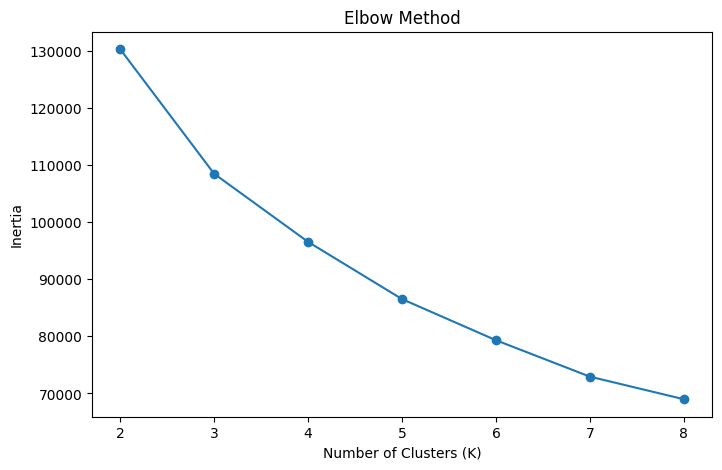

In [29]:
plt.figure(figsize=(8, 5))

plt.plot(
    list(k_values),
    inertia,
    marker='o'
)

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')

plt.xticks(list(k_values))

plt.show()

# 12. Silhouette score

In [30]:
silhouette_scores = []

for k in range(2, 7):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_sample)

    score = silhouette_score(
        X_sample,
        labels
    )

    silhouette_scores.append(score)

    print(
        f"K = {k}, "
        f"Silhouette Score = {score:.4f}"
    )

K = 2, Silhouette Score = 0.2729
K = 3, Silhouette Score = 0.2839
K = 4, Silhouette Score = 0.3005
K = 5, Silhouette Score = 0.3022
K = 6, Silhouette Score = 0.3068


# 13. Select K = 6

For this project, continue with six clusters because this is the segmentation structure we have already developed and profiled.

In [31]:
final_k = 6

print("Final K:", final_k)

Final K: 6


# 14. Train the final K-Means model

This is the actual clustering step.

In [32]:
final_kmeans = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=10
)

model_df['final_cluster'] = (
    final_kmeans.fit_predict(X)
)

print(
    model_df['final_cluster']
    .value_counts()
    .sort_index()
)

final_cluster
0    126825
1     21846
2     33590
3     63070
4     17664
5     13851
Name: count, dtype: int64


# 15. Final silhouette score

Instead of using the sample score as the final model-quality measurement, calculate the score on a representative sample from the final fitted model.

Calculating silhouette on all 276k rows can consume a lot of memory.

In [33]:
silhouette_sample_size = min(
    20000,
    len(X)
)

silhouette_idx = np.random.RandomState(42).choice(
    len(X),
    size=silhouette_sample_size,
    replace=False
)

final_silhouette = silhouette_score(
    X[silhouette_idx],
    model_df['final_cluster'].iloc[
        silhouette_idx
    ]
)

print(
    f"Final Silhouette Score: "
    f"{final_silhouette:.4f}"
)

Final Silhouette Score: 0.3065


# 16. Cluster sizes

In [34]:
cluster_counts = (
    model_df['final_cluster']
    .value_counts()
    .sort_index()
)

cluster_counts

final_cluster
0    126825
1     21846
2     33590
3     63070
4     17664
5     13851
Name: count, dtype: int64

In [35]:
cluster_share = (
    cluster_counts
    .rename_axis('final_cluster')
    .reset_index(name='listings')
)

cluster_share['percentage'] = (
    cluster_share['listings']
    / cluster_share['listings'].sum()
    * 100
)

cluster_share.round(2)

,final_cluster,listings,percentage
0,0,126825,45.81
1,1,21846,7.89
2,2,33590,12.13
3,3,63070,22.78
4,4,17664,6.38
5,5,13851,5.00


# 17. Profile the clusters

This is one of the most important sections of the notebook.

In [36]:
cluster_profile = (
    model_df
    .groupby('final_cluster')
    .agg(
        listings=('listing_id', 'count'),

        avg_price_usd=('price_usd', 'mean'),
        median_price_usd=('price_usd', 'median'),

        avg_relative_price=(
            'price_vs_city_median',
            'mean'
        ),

        avg_accommodates=('accommodates', 'mean'),

        avg_bedrooms=('bedrooms', 'mean'),

        avg_minimum_nights=(
            'minimum_nights',
            'mean'
        ),

        avg_rating=(
            'review_scores_rating',
            'mean'
        ),

        avg_reviews=(
            'total_reviews',
            'mean'
        ),

        avg_host_listings=(
            'host_total_listings_count',
            'mean'
        ),

        rating_missing_rate=(
            'rating_missing',
            'mean'
        )
    )
)

cluster_profile

,listings,avg_price_usd,median_price_usd,avg_relative_price,avg_accommodates,avg_bedrooms,avg_minimum_nights,avg_rating,avg_reviews,avg_host_listings,rating_missing_rate
final_cluster,,,,,,,,,,,
0,126825,78.746362,65.065000,1.078166,2.950704,1.262748,2.426706,95.779783,33.989600,2.964171,0.000000
1,21846,314.266120,259.461062,4.694106,7.802573,3.562666,5.544631,95.695825,14.609173,9.883320,0.351323
2,33590,98.463433,76.895000,1.137585,2.523072,1.217624,41.046294,95.448377,14.732599,2.696130,0.349568
3,63070,81.117124,60.120000,1.296056,2.716870,1.256318,2.713858,96.000000,0.069114,2.420089,1.000000
4,17664,107.319872,80.270184,1.555149,3.332314,1.365602,10.089561,94.001755,10.340410,306.183311,0.400815
5,13851,75.585701,59.150000,1.072636,2.993863,1.298679,4.420908,67.327052,2.924699,8.038120,0.000000


In [37]:
# Round the results

cluster_profile.round(2)

,listings,avg_price_usd,median_price_usd,avg_relative_price,avg_accommodates,avg_bedrooms,avg_minimum_nights,avg_rating,avg_reviews,avg_host_listings,rating_missing_rate
final_cluster,,,,,,,,,,,
0,126825,78.75,65.06,1.08,2.95,1.26,2.43,95.78,33.99,2.96,0.00
1,21846,314.27,259.46,4.69,7.80,3.56,5.54,95.70,14.61,9.88,0.35
2,33590,98.46,76.90,1.14,2.52,1.22,41.05,95.45,14.73,2.70,0.35
3,63070,81.12,60.12,1.30,2.72,1.26,2.71,96.00,0.07,2.42,1.00
4,17664,107.32,80.27,1.56,3.33,1.37,10.09,94.00,10.34,306.18,0.40
5,13851,75.59,59.15,1.07,2.99,1.30,4.42,67.33,2.92,8.04,0.00


# 18. Add percentage

In [38]:
cluster_profile['percentage'] = (
    cluster_profile['listings']
    / cluster_profile['listings'].sum()
    * 100
)

cluster_profile.round(2)

,listings,avg_price_usd,median_price_usd,avg_relative_price,avg_accommodates,avg_bedrooms,avg_minimum_nights,avg_rating,avg_reviews,avg_host_listings,rating_missing_rate,percentage
final_cluster,,,,,,,,,,,,
0,126825,78.75,65.06,1.08,2.95,1.26,2.43,95.78,33.99,2.96,0.00,45.81
1,21846,314.27,259.46,4.69,7.80,3.56,5.54,95.70,14.61,9.88,0.35,7.89
2,33590,98.46,76.90,1.14,2.52,1.22,41.05,95.45,14.73,2.70,0.35,12.13
3,63070,81.12,60.12,1.30,2.72,1.26,2.71,96.00,0.07,2.42,1.00,22.78
4,17664,107.32,80.27,1.56,3.33,1.37,10.09,94.00,10.34,306.18,0.40,6.38
5,13851,75.59,59.15,1.07,2.99,1.30,4.42,67.33,2.92,8.04,0.00,5.00


# 19. Understand each cluster

Instead of blindly assigning names, inspect the profile first.

In [39]:
cluster_profile.sort_values(
    'listings',
    ascending=False
).round(2)

,listings,avg_price_usd,median_price_usd,avg_relative_price,avg_accommodates,avg_bedrooms,avg_minimum_nights,avg_rating,avg_reviews,avg_host_listings,rating_missing_rate,percentage
final_cluster,,,,,,,,,,,,
0,126825,78.75,65.06,1.08,2.95,1.26,2.43,95.78,33.99,2.96,0.00,45.81
3,63070,81.12,60.12,1.30,2.72,1.26,2.71,96.00,0.07,2.42,1.00,22.78
2,33590,98.46,76.90,1.14,2.52,1.22,41.05,95.45,14.73,2.70,0.35,12.13
1,21846,314.27,259.46,4.69,7.80,3.56,5.54,95.70,14.61,9.88,0.35,7.89
4,17664,107.32,80.27,1.56,3.33,1.37,10.09,94.00,10.34,306.18,0.40,6.38
5,13851,75.59,59.15,1.07,2.99,1.30,4.42,67.33,2.92,8.04,0.00,5.00


# 20. Final cluster names

Based on the segmentation that already established, use:

In [40]:
final_cluster_names = {
    0: 'Long-Stay Listings',
    1: 'New / Low-Review Listings',
    2: 'Established Mainstream',
    3: 'Professional Hosts',
    4: 'Low-Rated Listings',
    5: 'Premium Large Properties'
}

model_df['final_cluster_name'] = (
    model_df['final_cluster']
    .map(final_cluster_names)
)

# 21. Verify the names

In [41]:
model_df[
    [
        'final_cluster',
        'final_cluster_name'
    ]
].drop_duplicates().sort_values(
    'final_cluster'
)

,final_cluster,final_cluster_name
3808,0,Long-Stay Listings
9,1,New / Low-Review Listings
15,2,Established Mainstream
0,3,Professional Hosts
505,4,Low-Rated Listings
3897,5,Premium Large Properties


# 22. Final segment distribution

In [42]:
final_cluster_share = (
    model_df['final_cluster_name']
    .value_counts()
    .rename_axis('cluster_name')
    .reset_index(name='listings')
)

final_cluster_share['percentage'] = (
    final_cluster_share['listings']
    / final_cluster_share['listings'].sum()
    * 100
)

final_cluster_share.round(2)

,cluster_name,listings,percentage
0,Long-Stay Listings,126825,45.81
1,Professional Hosts,63070,22.78
2,Established Mainstream,33590,12.13
3,New / Low-Review Listings,21846,7.89
4,Low-Rated Listings,17664,6.38
5,Premium Large Properties,13851,5.00


# 23. Dominant city for each segment

In [43]:
city_distribution = (
    model_df
    .groupby(
        [
            'final_cluster_name',
            'city'
        ]
    )
    .size()
    .reset_index(name='listings')
)

top_city = (
    city_distribution
    .sort_values(
        [
            'final_cluster_name',
            'listings'
        ],
        ascending=[True, False]
    )
    .groupby('final_cluster_name')
    .head(1)
    .sort_values('final_cluster_name')
)

top_city

,final_cluster_name,city,listings
5,Established Mainstream,New York,21802
16,Long-Stay Listings,Paris,37819
26,Low-Rated Listings,Paris,3307
39,New / Low-Review Listings,Sydney,3923
46,Premium Large Properties,Paris,3604
56,Professional Hosts,Paris,13727


# 24. Dominant room type

In [44]:
room_distribution = (
    model_df
    .groupby(
        [
            'final_cluster_name',
            'room_type'
        ]
    )
    .size()
    .reset_index(name='listings')
)

top_room_type = (
    room_distribution
    .sort_values(
        [
            'final_cluster_name',
            'listings'
        ],
        ascending=[True, False]
    )
    .groupby('final_cluster_name')
    .head(1)
    .sort_values('final_cluster_name')
)

top_room_type

,final_cluster_name,room_type,listings
0,Established Mainstream,Entire place,19600
4,Long-Stay Listings,Entire place,87374
8,Low-Rated Listings,Entire place,13411
12,New / Low-Review Listings,Entire place,19949
16,Premium Large Properties,Entire place,8201
20,Professional Hosts,Entire place,31436


# 25. Segment profile with useful business metrics

In [45]:
final_profile = (
    model_df
    .groupby(
        [
            'final_cluster',
            'final_cluster_name'
        ]
    )
    .agg(
        listings=('listing_id', 'count'),

        avg_price_usd=('price_usd', 'mean'),
        median_price_usd=('price_usd', 'median'),

        avg_relative_price=(
            'price_vs_city_median',
            'mean'
        ),

        avg_capacity=('accommodates', 'mean'),

        avg_bedrooms=('bedrooms', 'mean'),

        avg_minimum_stay=(
            'minimum_nights',
            'mean'
        ),

        avg_rating=(
            'review_scores_rating',
            'mean'
        ),

        avg_reviews=(
            'total_reviews',
            'mean'
        ),

        avg_host_portfolio=(
            'host_total_listings_count',
            'mean'
        )
    )
    .reset_index()
)

final_profile['percentage'] = (
    final_profile['listings']
    / final_profile['listings'].sum()
    * 100
)

final_profile.round(2)

,final_cluster,final_cluster_name,listings,avg_price_usd,median_price_usd,avg_relative_price,avg_capacity,avg_bedrooms,avg_minimum_stay,avg_rating,avg_reviews,avg_host_portfolio,percentage
0,0,Long-Stay Listings,126825,78.75,65.06,1.08,2.95,1.26,2.43,95.78,33.99,2.96,45.81
1,1,New / Low-Review Listings,21846,314.27,259.46,4.69,7.80,3.56,5.54,95.70,14.61,9.88,7.89
2,2,Established Mainstream,33590,98.46,76.90,1.14,2.52,1.22,41.05,95.45,14.73,2.70,12.13
3,3,Professional Hosts,63070,81.12,60.12,1.30,2.72,1.26,2.71,96.00,0.07,2.42,22.78
4,4,Low-Rated Listings,17664,107.32,80.27,1.56,3.33,1.37,10.09,94.00,10.34,306.18,6.38
5,5,Premium Large Properties,13851,75.59,59.15,1.07,2.99,1.30,4.42,67.33,2.92,8.04,5.00


# 26. Visualize cluster sizes

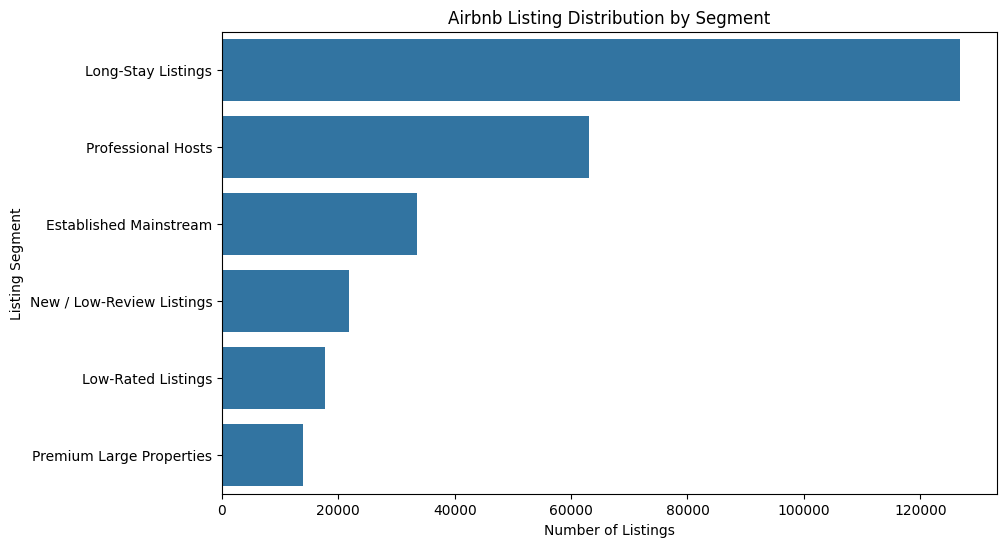

In [46]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=final_profile.sort_values(
        'listings',
        ascending=False
    ),
    x='listings',
    y='final_cluster_name'
)

plt.xlabel('Number of Listings')
plt.ylabel('Listing Segment')
plt.title('Airbnb Listing Distribution by Segment')

plt.show()

# 27. Relative price vs reviews
This is useful for visually explaining the segmentation.

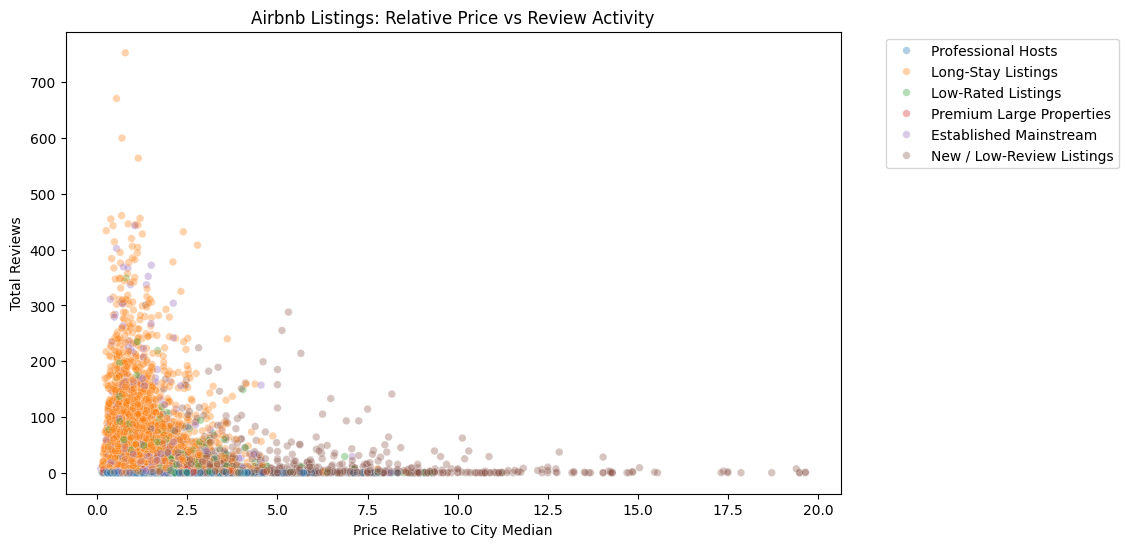

In [47]:
plot_df = model_df.sample(
    min(15000, len(model_df)),
    random_state=42
)

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=plot_df,
    x='price_vs_city_median',
    y='total_reviews',
    hue='final_cluster_name',
    alpha=0.35,
    s=30
)

plt.xlabel('Price Relative to City Median')
plt.ylabel('Total Reviews')
plt.title(
    'Airbnb Listings: Relative Price vs Review Activity'
)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.show()

# 28. Relative price vs capacity

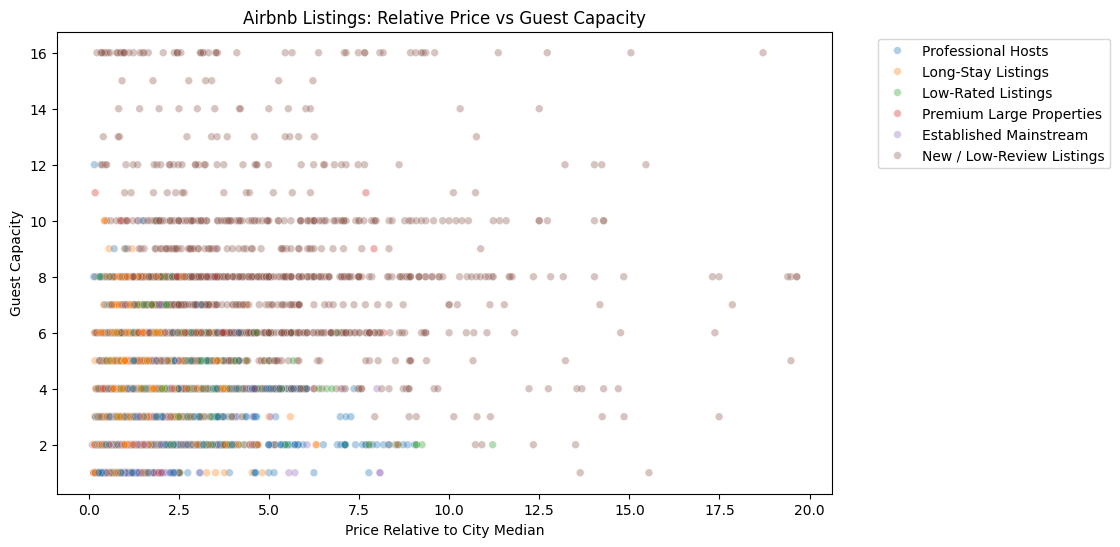

In [48]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=plot_df,
    x='price_vs_city_median',
    y='accommodates',
    hue='final_cluster_name',
    alpha=0.35,
    s=30
)

plt.xlabel('Price Relative to City Median')
plt.ylabel('Guest Capacity')
plt.title(
    'Airbnb Listings: Relative Price vs Guest Capacity'
)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.show()

# 29. Reviews vs minimum stay

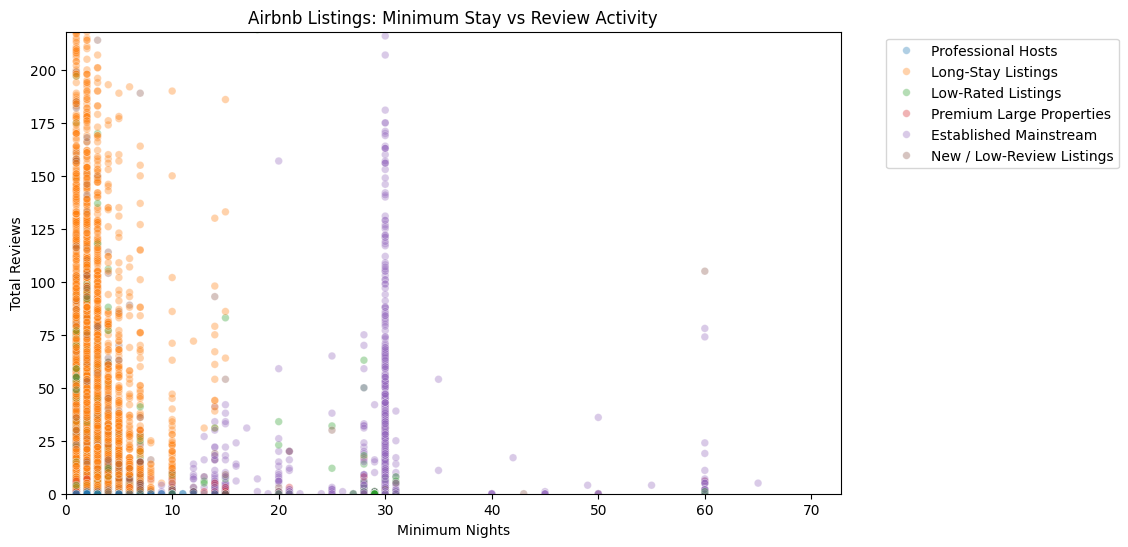

In [49]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=plot_df,
    x='minimum_nights',
    y='total_reviews',
    hue='final_cluster_name',
    alpha=0.35,
    s=30
)

plt.xlabel('Minimum Nights')
plt.ylabel('Total Reviews')
plt.title(
    'Airbnb Listings: Minimum Stay vs Review Activity'
)

plt.xlim(
    0,
    model_df['minimum_nights'].quantile(0.99)
)

plt.ylim(
    0,
    model_df['total_reviews'].quantile(0.99)
)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.show()

# 30. Prepare final dataset

Now create the exact dataset that goes into SQL Server.

In [50]:
final_columns = [
    'listing_id',
    'name',
    'city',
    'neighbourhood',
    'room_type',
    'property_type',

    'price',
    'price_usd',
    'price_vs_city_median',

    'accommodates',
    'bedrooms',
    'minimum_nights',
    'review_scores_rating',
    'total_reviews',
    'host_is_superhost',
    'host_tenure_years',
    'host_total_listings_count',
    'review_status',
    'final_cluster',
    'final_cluster_name'
]

final_df = model_df[final_columns].copy()

print("Final dataset shape:", final_df.shape)

final_df.head()

Final dataset shape: (276846, 20)


,listing_id,name,city,neighbourhood,room_type,property_type,price,price_usd,price_vs_city_median,accommodates,bedrooms,minimum_nights,review_scores_rating,total_reviews,host_is_superhost,host_tenure_years,host_total_listings_count,review_status,final_cluster,final_cluster_name
0,45659431,Entire Large 2 Bedroom - Crown Heights,New York,Crown Heights,Entire place,Entire apartment,60.0,60.000000,0.606061,4,2.0,10,96.0,0,f,3.0,1.0,No Reviews,3,Professional Hosts
1,48108359,Lugar perfecto para trabajar y sentir tranquil...,Mexico City,Miguel Hidalgo,Entire place,Entire apartment,328.0,16.170062,0.493976,2,1.0,2,96.0,0,f,5.0,1.0,No Reviews,3,Professional Hosts
2,46541258,"Apartamento simples, mas acolhedor.",Rio de Janeiro,Gloria,Entire place,Entire apartment,359.0,66.533230,1.282143,4,1.0,3,96.0,0,f,1.0,1.0,No Reviews,3,Professional Hosts
3,39838451,2 piÃ¨ces Paris 11 proche Republique,Paris,Popincourt,Entire place,Entire apartment,100.0,118.300000,1.250000,5,1.0,2,96.0,0,f,5.0,1.0,No Reviews,3,Professional Hosts
4,45965639,Rio de janeiro - Vicente de Carvalho / Iraja.,Rio de Janeiro,Vicente de Carvalho,Entire place,Entire apartment,89.0,16.494310,0.317857,3,2.0,3,96.0,0,f,1.0,1.0,No Reviews,3,Professional Hosts


# 31. Validate final dataset

In [51]:
print("Missing values:")
print(final_df.isnull().sum())

Missing values:
listing_id                     0
name                         167
city                           0
neighbourhood                  0
room_type                      0
property_type                  0
price                          0
price_usd                      0
price_vs_city_median           0
accommodates                   0
bedrooms                       0
minimum_nights                 0
review_scores_rating           0
total_reviews                  0
host_is_superhost            165
host_tenure_years            165
host_total_listings_count      0
review_status                  0
final_cluster                  0
final_cluster_name             0
dtype: int64


In [52]:
print(
    "Duplicate listing IDs:",
    final_df['listing_id'].duplicated().sum()
)

Duplicate listing IDs: 0


In [53]:
print(
    "Unique listings:",
    final_df['listing_id'].nunique()
)

Unique listings: 276846


# 32. Fix integer columns for SQL Server

This is the part that needed because SQL Server was having conversion issues with pandas float64 values.

In [54]:
final_df['bedrooms'] = (
    final_df['bedrooms']
    .astype('Int64')
)

int_columns = [
    'listing_id',
    'accommodates',
    'bedrooms',
    'minimum_nights',
    'total_reviews',
    'host_tenure_years',
    'host_total_listings_count',
    'final_cluster'
]

for col in int_columns:
    final_df[col] = (
        final_df[col]
        .astype('Int64')
    )

# 33. Final validation

In [55]:
final_df.dtypes

listing_id                     Int64
name                          object
city                          object
neighbourhood                 object
room_type                     object
property_type                 object
price                        float64
price_usd                    float64
price_vs_city_median         float64
accommodates                   Int64
bedrooms                       Int64
minimum_nights                 Int64
review_scores_rating         float64
total_reviews                  Int64
host_is_superhost             object
host_tenure_years              Int64
host_total_listings_count      Int64
review_status                 object
final_cluster                  Int64
final_cluster_name            object
dtype: object

In [56]:
final_df.dtypes

listing_id                     Int64
name                          object
city                          object
neighbourhood                 object
room_type                     object
property_type                 object
price                        float64
price_usd                    float64
price_vs_city_median         float64
accommodates                   Int64
bedrooms                       Int64
minimum_nights                 Int64
review_scores_rating         float64
total_reviews                  Int64
host_is_superhost             object
host_tenure_years              Int64
host_total_listings_count      Int64
review_status                 object
final_cluster                  Int64
final_cluster_name            object
dtype: object

In [57]:
final_df.shape

(276846, 20)

# 34. Export final clustering dataset

In [ ]:
output_path = (
    r'E:\All\Data Analysis\Projects\Airbnb'
    r'\final_airbnb_clusters.csv'
)

final_df.to_csv(
    output_path,
    index=False,
    encoding='utf-8-sig'
)

print("Saved successfully:")
print(output_path)

Saved successfully:
E:\All\Data Analysis\Projects\Airbnb\fienal_airbnb_clusters.csv


# 35. Final verification after export

In [59]:
check_df = pd.read_csv(
    output_path,
    encoding='utf-8-sig'
)

print("Exported shape:", check_df.shape)
print(
    "Unique listings:",
    check_df['listing_id'].nunique()
)

print()
print(
    check_df['final_cluster_name']
    .value_counts()
)

Exported shape: (276846, 20)
Unique listings: 276846

final_cluster_name
Long-Stay Listings           126825
Professional Hosts            63070
Established Mainstream        33590
New / Low-Review Listings     21846
Low-Rated Listings            17664
Premium Large Properties      13851
Name: count, dtype: int64
